In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [63]:
orders_ml = pd.read_parquet('../data/processed/orders_ml_clean.parquet')
order_items = pd.read_parquet('../data/processed/order_items_clean.parquet')
payments = pd.read_parquet('../data/processed/payments_clean.parquet')
customers = pd.read_parquet('../data/processed/customers_clean.parquet')
products = pd.read_parquet('../data/processed/products_clean.parquet')

In [64]:
# Start with orders
df = orders_ml.copy()

# Merge payments (target)
df = df.merge(payments, on='order_id', how='left')

# Merge order items
df = df.merge(order_items, on='order_id', how='left')

# Merge customers
df = df.merge(customers, on='customer_id', how='left')

df = df.merge(products, on='product_id', how='left')

print("Final shape:", df.shape)
df.head()

Final shape: (87413, 24)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,...,shipping_charges,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,1,credit_card,1,...,84.65,58125,varzea paulista,SP,toys,491.0,19.0,12.0,16.0,3648.0
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,1,credit_card,8,...,23.79,3112,armacao dos buzios,RJ,watches_gifts,440.0,18.0,14.0,17.0,4284.0
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,1,credit_card,4,...,17.38,4119,jandira,SP,costruction_tools_garden,2200.0,16.0,16.0,16.0,4096.0
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,1,credit_card,2,...,30.72,18212,uberlandia,MG,toys,1450.0,68.0,3.0,48.0,9792.0
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,1,credit_card,1,...,30.66,88868,ilhabela,SP,toys,300.0,17.0,4.0,12.0,816.0


In [65]:
df.to_parquet("../data/processed/df_eda.parquet", index=False)

# DATA OVERVIEW

In [66]:
print(df.shape)
print(df.info())
print(df.describe())

(87413, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87413 entries, 0 to 87412
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       87413 non-null  object        
 1   customer_id                    87413 non-null  object        
 2   order_status                   87413 non-null  category      
 3   order_purchase_timestamp       87413 non-null  datetime64[ns]
 4   order_approved_at              87413 non-null  datetime64[ns]
 5   order_delivered_timestamp      87413 non-null  datetime64[ns]
 6   order_estimated_delivery_date  87413 non-null  datetime64[ns]
 7   payment_sequential             87413 non-null  int64         
 8   payment_type                   87413 non-null  category      
 9   payment_installments           87413 non-null  int16         
 10  payment_value                  87413 non-null  float64       
 11  pro

# BASIC DISTRIBUTIONS

## Payment Distribution

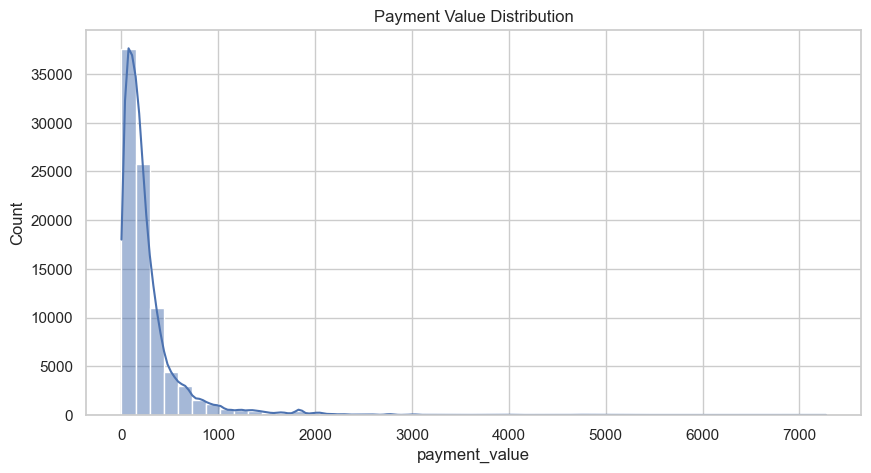

In [67]:
sns.histplot(df['payment_value'], bins=50, kde=True)
plt.title("Payment Value Distribution")
plt.show()

### Insight

## Product Volume

Text(0.5, 1.0, 'Product Volume Distribution')

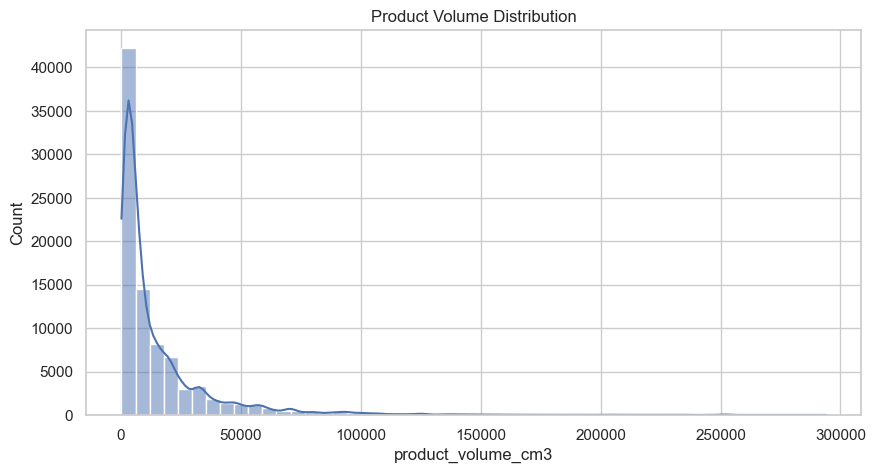

In [68]:
sns.histplot(df['product_volume_cm3'], bins=50, kde=True)
plt.title("Product Volume Distribution")

### Insight

## Shipping Charges

Text(0.5, 1.0, 'Shipping Charges Distribution')

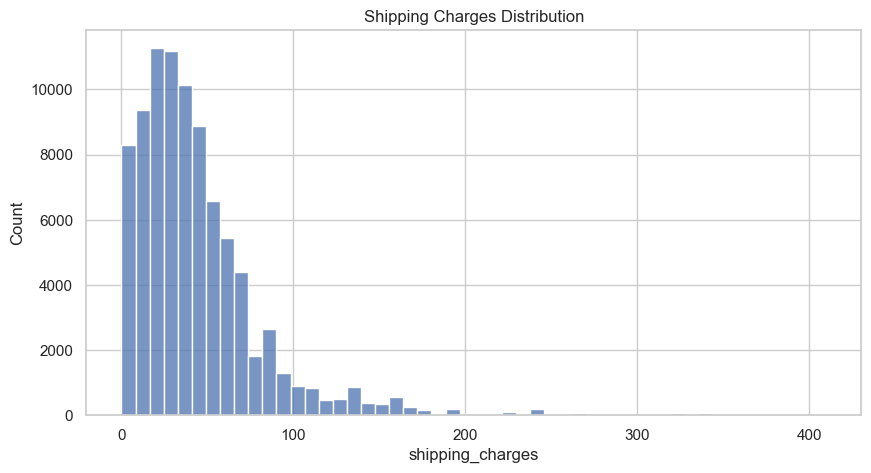

In [69]:
sns.histplot(df['shipping_charges'], bins=50)
plt.title("Shipping Charges Distribution")

### Insight

# LOG TRANSFORM

Text(0.5, 1.0, 'Log Payment Value')

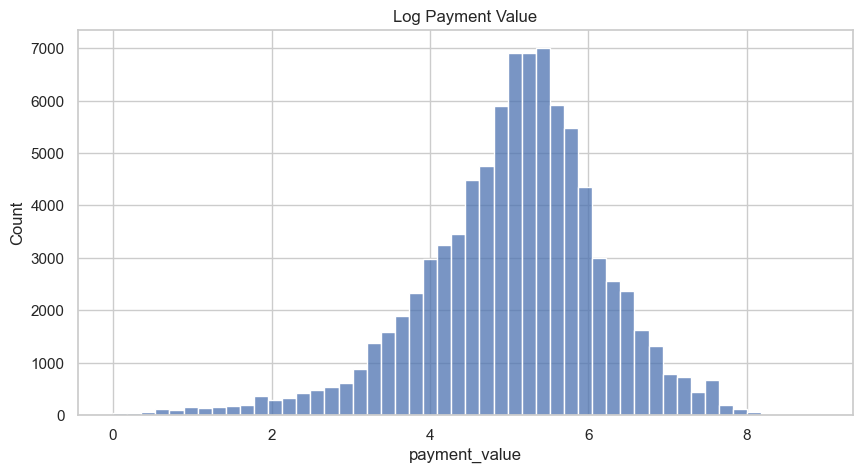

In [70]:
sns.histplot(np.log1p(df['payment_value']), bins=50)
plt.title("Log Payment Value")

### Insight

# CATEGORICAL ANALYSIS

## Payment Type

Text(0.5, 1.0, 'Payment Type Distribution')

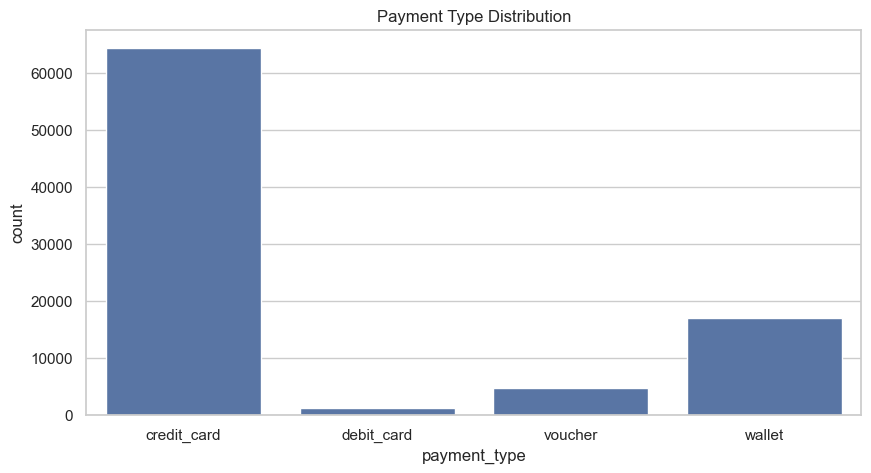

In [71]:
sns.countplot(x='payment_type', data=df)
plt.title("Payment Type Distribution")

### Insight

## Orders by State

Text(0.5, 1.0, 'Top States by Orders')

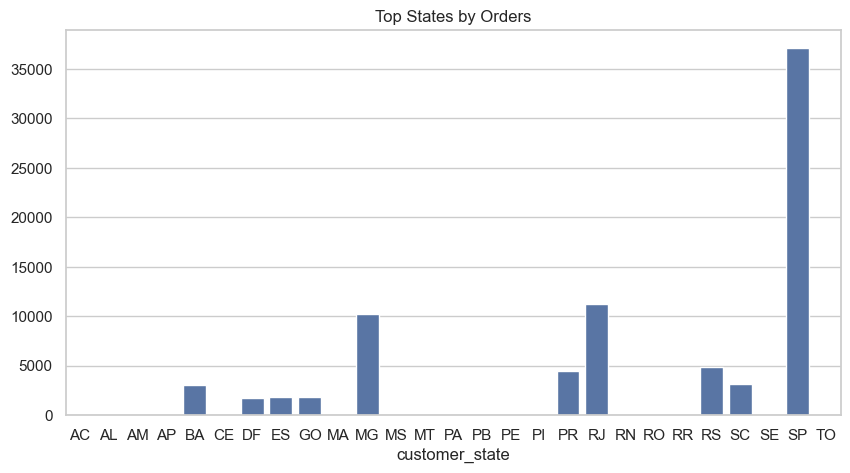

In [72]:
top_states = df['customer_state'].value_counts().head(10)

sns.barplot(x=top_states.index, y=top_states.values)
plt.title("Top States by Orders")

### Insight

## Product Categories

Text(0.5, 1.0, 'Top Product Categories')

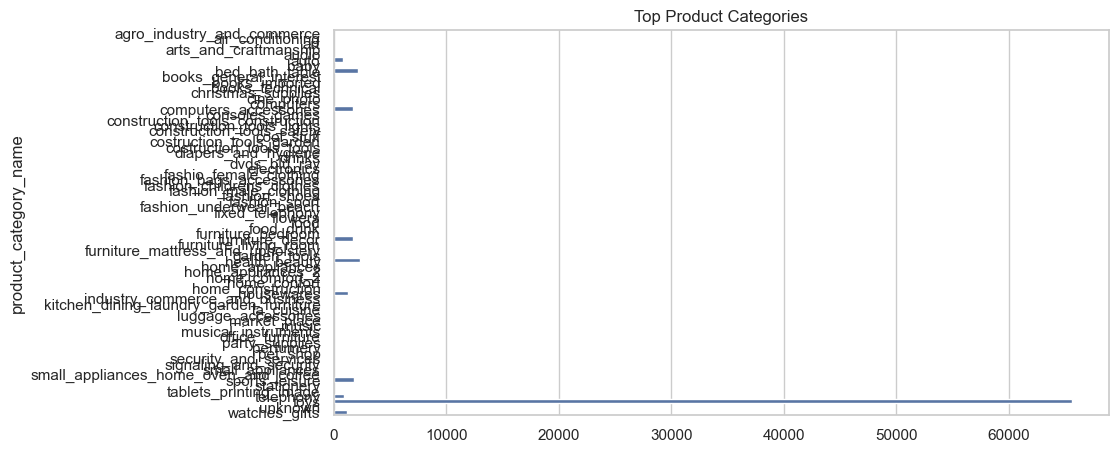

In [73]:
top_cat = df['product_category_name'].value_counts().head(10)

sns.barplot(x=top_cat.values, y=top_cat.index)
plt.title("Top Product Categories")

### Insight

# TIME SERIES ANALYSIS

## Orders Over Time

Text(0.5, 1.0, 'Orders Over Time')

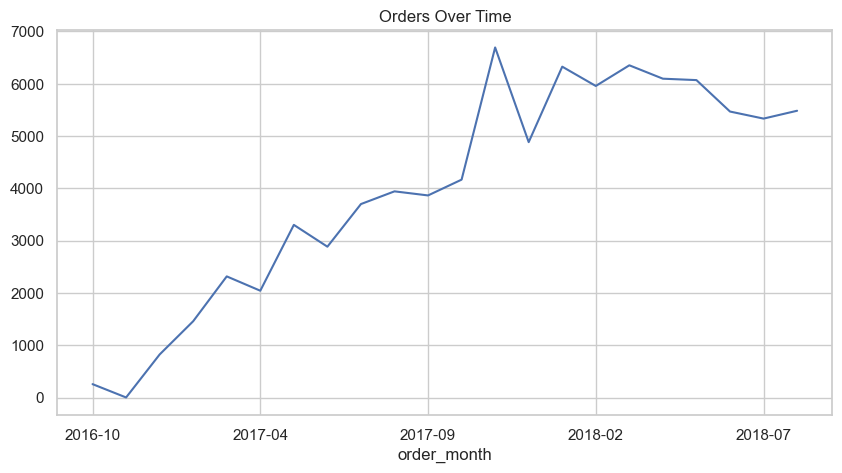

In [74]:
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

monthly_orders = df.groupby('order_month').size()

monthly_orders.plot()
plt.title("Orders Over Time")

### Insight

## Revenue Trend

Text(0.5, 1.0, 'Revenue Trend')

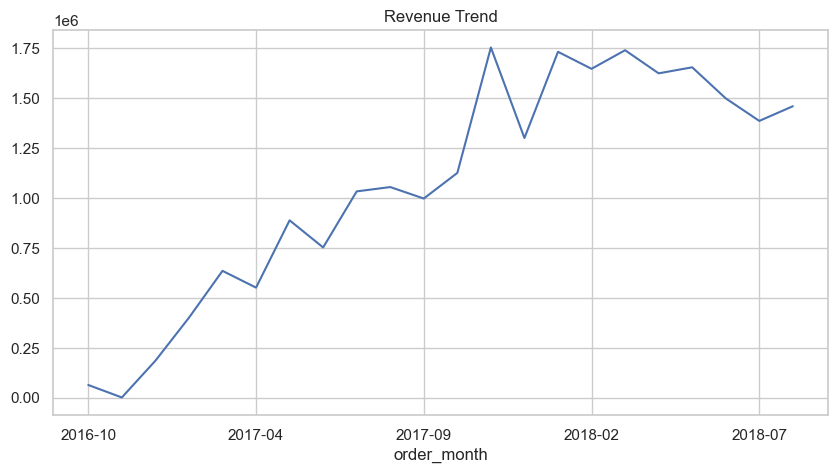

In [75]:
monthly_revenue = df.groupby('order_month')['payment_value'].sum()

monthly_revenue.plot()
plt.title("Revenue Trend")

### Insight

# FEATURE ENGINEERING

In [76]:
df['delivery_time_days'] = (
    df['order_delivered_timestamp'] - df['order_purchase_timestamp']
).dt.days

df['delay_days'] = (
    df['order_delivered_timestamp'] - df['order_estimated_delivery_date']
).dt.days

df['is_delayed'] = (df['delay_days'] > 0).astype(int)

df['high_value'] = (
    df['payment_value'] > df['payment_value'].quantile(0.75)
).astype(int)

# DELAY ANALYSIS

## Delay Distribution

Text(0.5, 1.0, 'Delivery Delay Distribution')

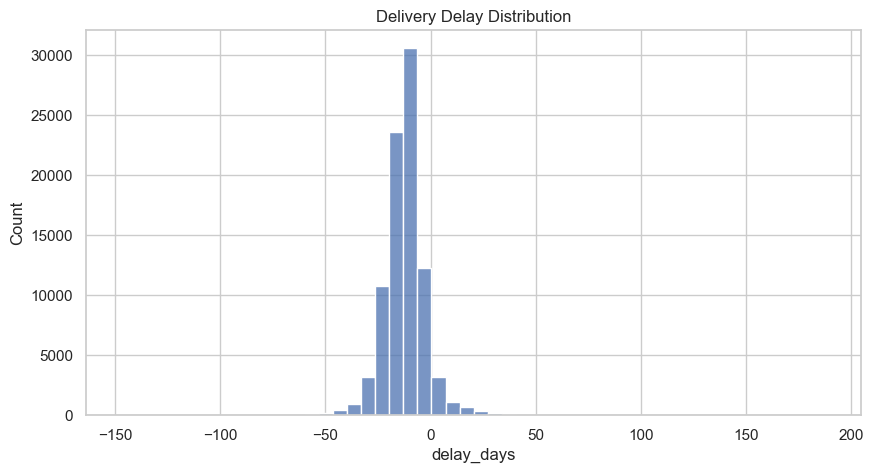

In [77]:
sns.histplot(df['delay_days'], bins=50)
plt.title("Delivery Delay Distribution")

### Insight

## Delay by State

C:\Users\Harsh\AppData\Local\Temp\ipykernel_36840\1419189450.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  state_delay = df.groupby("customer_state")["is_delayed"].mean().sort_values(ascending=False).head(10)


Text(0.5, 1.0, 'Top Delay States')

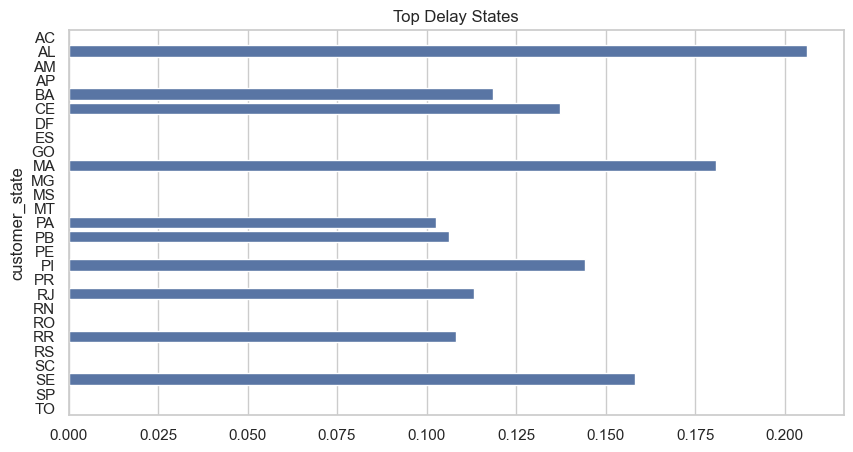

In [78]:
state_delay = df.groupby("customer_state")["is_delayed"].mean().sort_values(ascending=False).head(10)

sns.barplot(x=state_delay.values, y=state_delay.index)
plt.title("Top Delay States")

### Insight

## Delay by Category

C:\Users\Harsh\AppData\Local\Temp\ipykernel_36840\3329943658.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_delay = df.groupby("product_category_name")["is_delayed"].mean().sort_values(ascending=False).head(10)


Text(0.5, 1.0, 'Delay by Category')

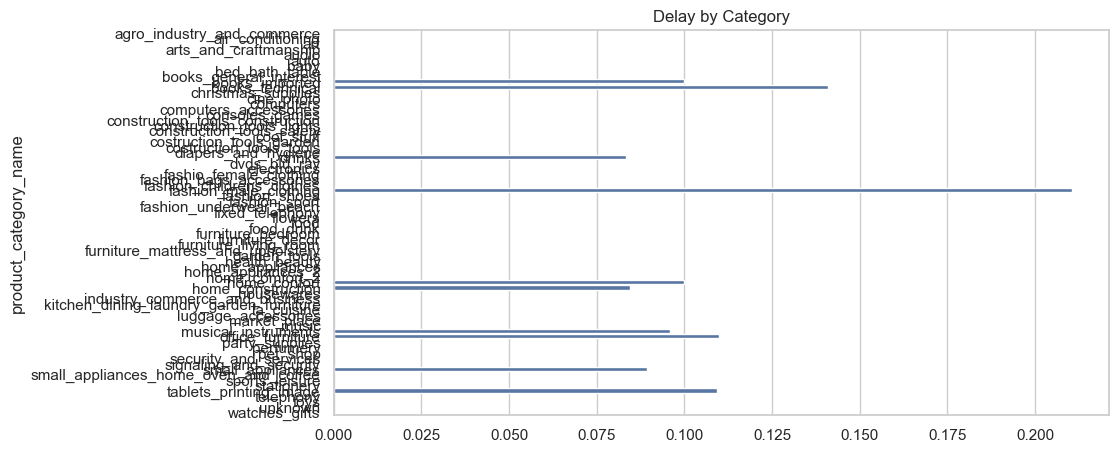

In [79]:
cat_delay = df.groupby("product_category_name")["is_delayed"].mean().sort_values(ascending=False).head(10)

sns.barplot(x=cat_delay.values, y=cat_delay.index)
plt.title("Delay by Category")

# HIGH VALUE ANALYSIS

## Payment Type vs Value

(0.0, 1000.0)

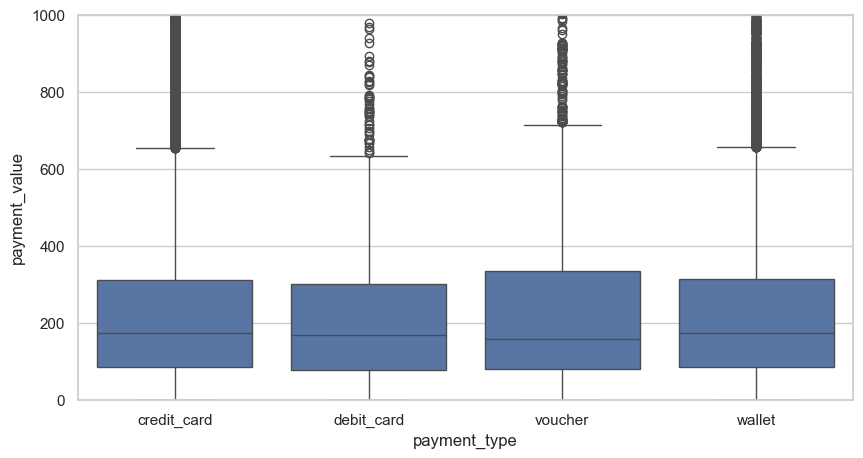

In [80]:
sns.boxplot(x="payment_type", y="payment_value", data=df)
plt.ylim(0, 1000)

### Insight

## Category vs Value

(0.0, 1000.0)

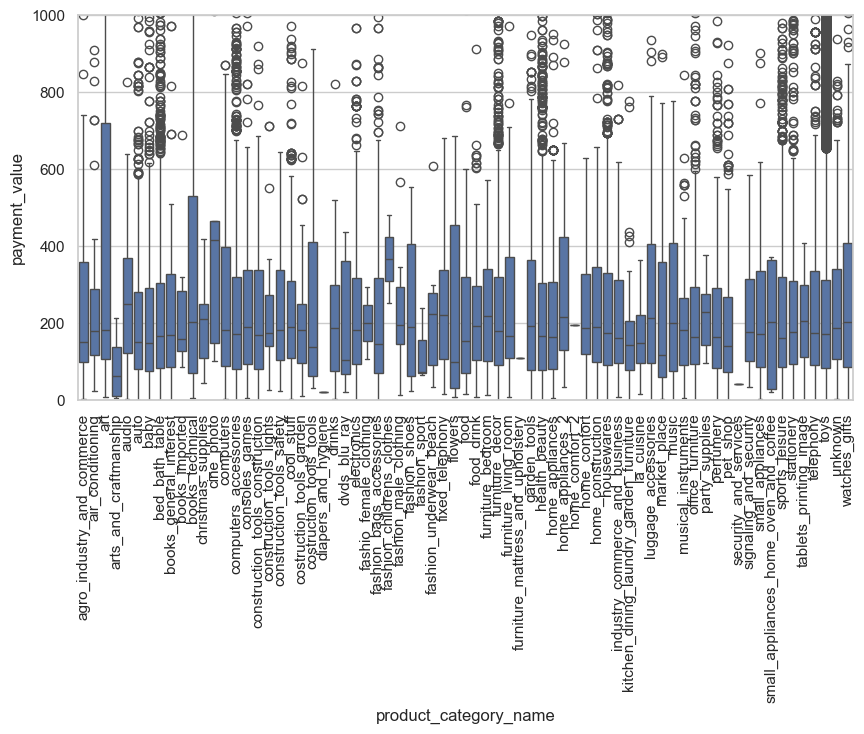

In [81]:
sns.boxplot(x="product_category_name", y="payment_value", data=df)
plt.xticks(rotation=90)
plt.ylim(0, 1000)

### Insight

# CORRELATION HEATMAP

<Axes: >

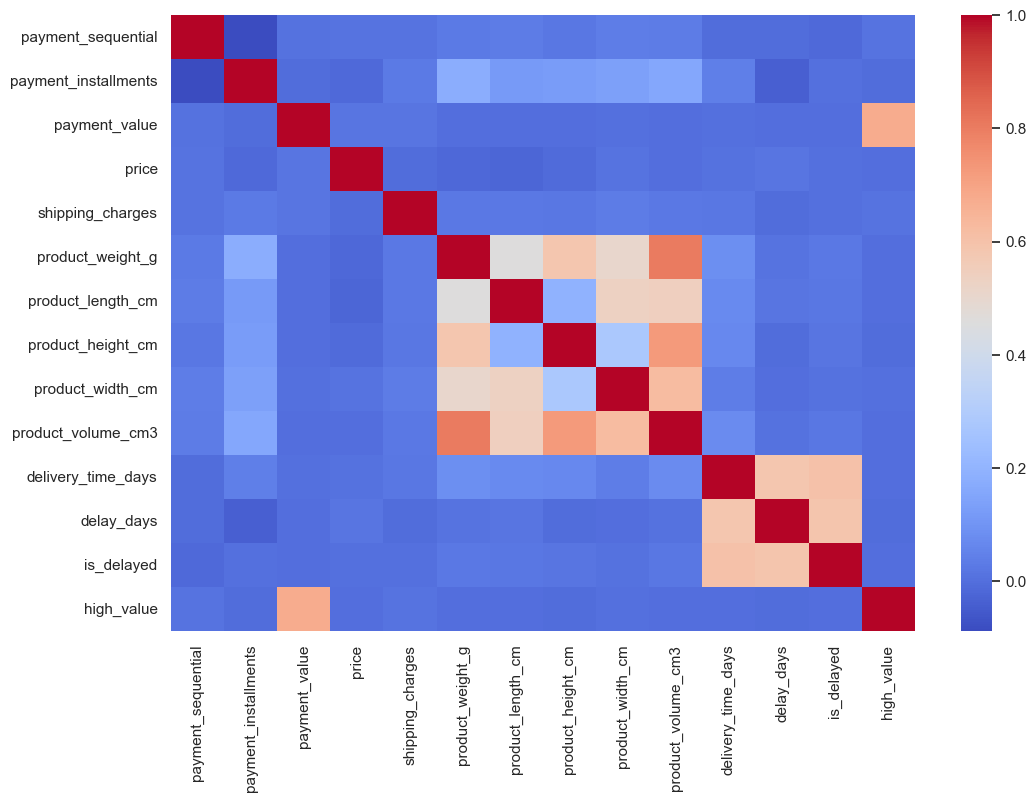

In [82]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

### Insight

# Bubble Plot

<Axes: xlabel='product_volume_cm3', ylabel='payment_value'>

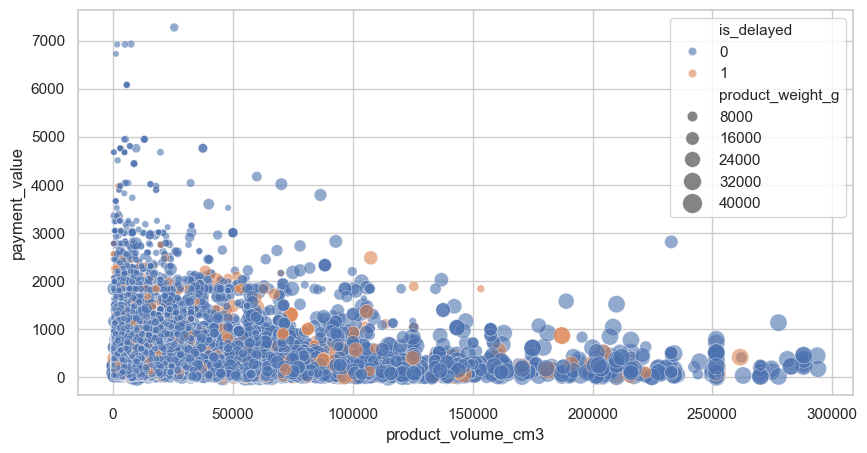

In [83]:
sns.scatterplot(
    x='product_volume_cm3',
    y='payment_value',
    size='product_weight_g',
    hue='is_delayed',
    data=df,
    sizes=(20, 200),
    alpha=0.6
)

### Insight

# Pairplot

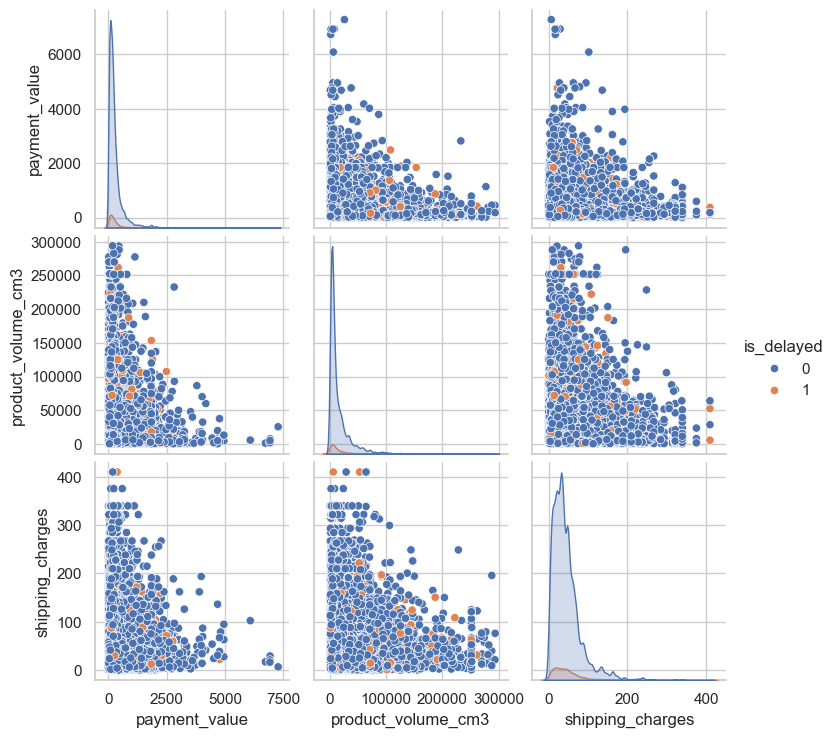

In [84]:
sns.pairplot(
    df[['payment_value','product_volume_cm3','shipping_charges','is_delayed']],
    hue='is_delayed'
)

# Violin Plot

<Axes: xlabel='is_delayed', ylabel='payment_value'>

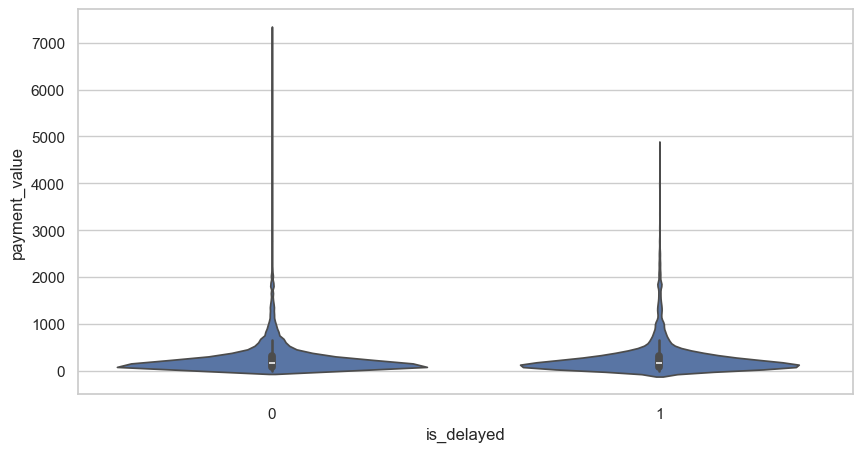

In [85]:
sns.violinplot(x="is_delayed", y="payment_value", data=df)

# FEATURE RELATIONSHIPS

## Volume vs Delay

<Axes: xlabel='is_delayed', ylabel='product_volume_cm3'>

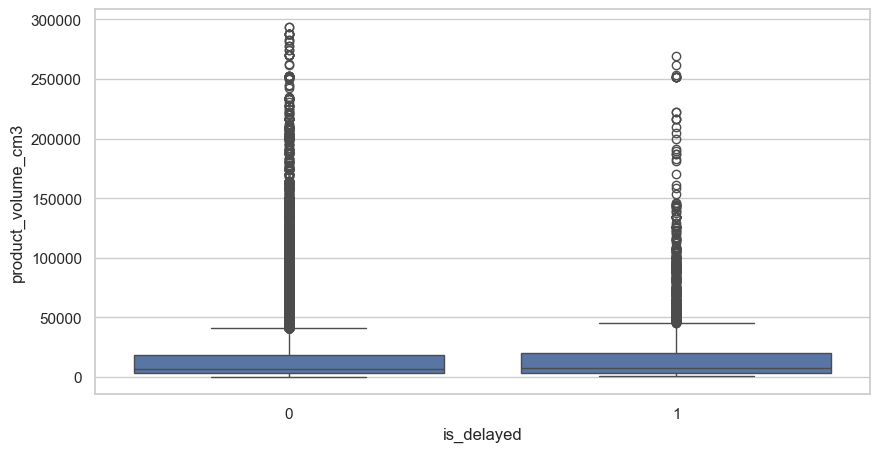

In [86]:
sns.boxplot(x="is_delayed", y="product_volume_cm3", data=df)

## Shipping vs Delay

<Axes: xlabel='shipping_charges', ylabel='delay_days'>

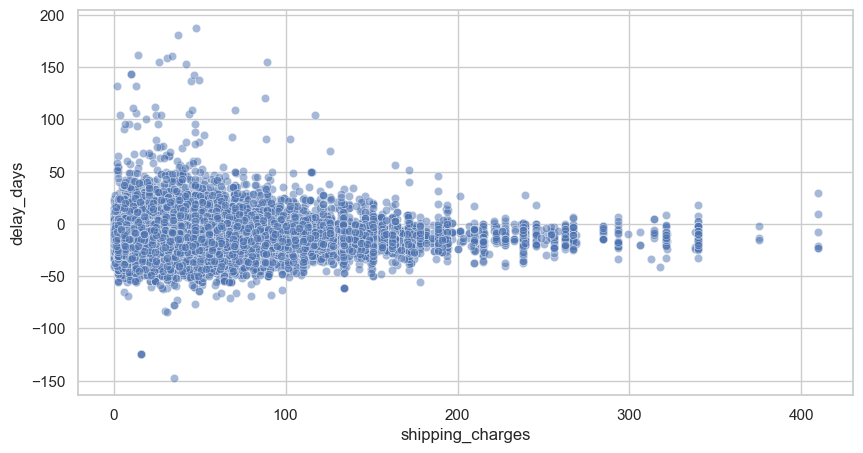

In [87]:
sns.scatterplot(
    x="shipping_charges",
    y="delay_days",
    data=df,
    alpha=0.5
)

# SEGMENTATION

In [88]:
df['segment'] = "Normal"

df.loc[(df['high_value']==1), 'segment'] = "High Value"
df.loc[(df['is_delayed']==1), 'segment'] = "Risk"

## Segment Count

<Axes: xlabel='segment', ylabel='count'>

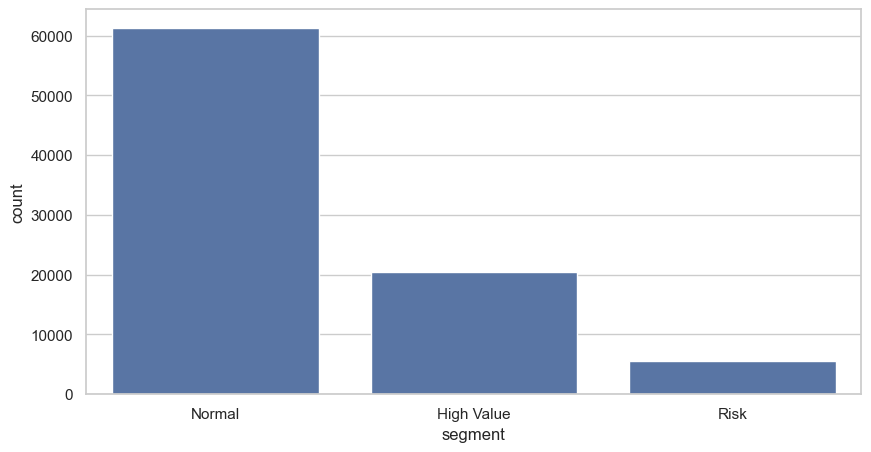

In [89]:
sns.countplot(x='segment', data=df)

# Heatmap

C:\Users\Harsh\AppData\Local\Temp\ipykernel_36840\1696738992.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


<Axes: xlabel='product_category_name', ylabel='customer_state'>

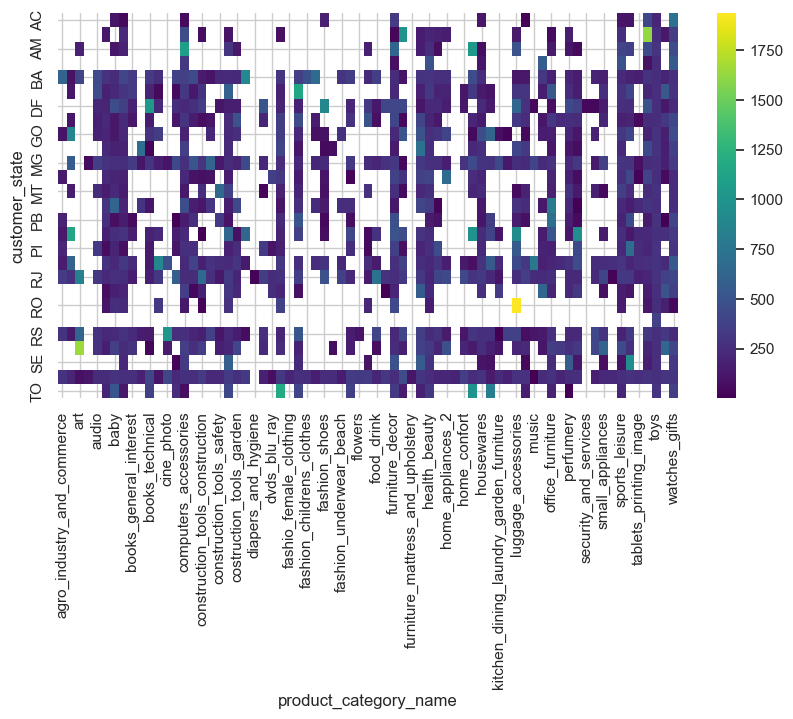

In [90]:
pivot = df.pivot_table(
    values='payment_value',
    index='customer_state',
    columns='product_category_name',
    aggfunc='mean'
)

sns.heatmap(pivot, cmap='viridis')

# KDE Plot

<Axes: xlabel='payment_value', ylabel='Density'>

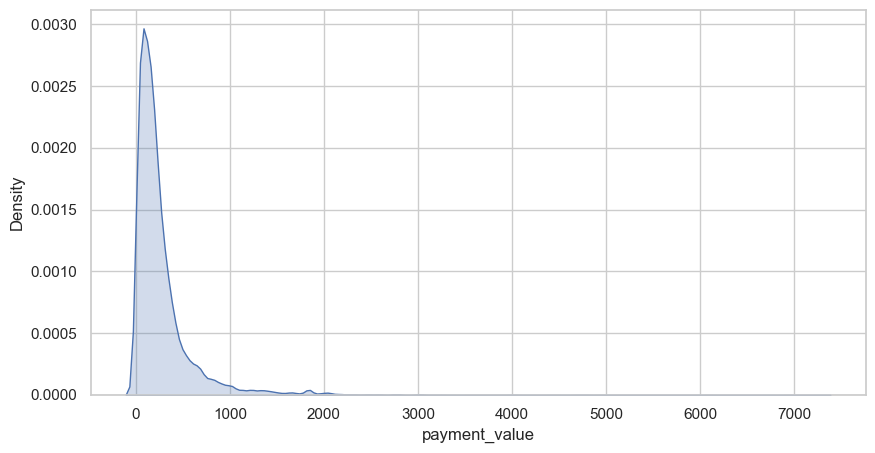

In [91]:
sns.kdeplot(df['payment_value'], fill=True)

# Final Insights